In [30]:
import sys

print(sys.executable)

/opt/homebrew/opt/python@3.11/bin/python3.11


In [31]:
import requests
from bs4 import BeautifulSoup

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import requests

url = "https://books.toscrape.com/"

response = requests.get(url)

print(response.status_code)

In [ ]:
import requests
from bs4 import BeautifulSoup

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import requests

url = "https://books.toscrape.com/"

response = requests.get(url)

print(response.status_code)


200


In [ ]:
import requests

url = "https://books.toscrape.com/"

response = requests.get(url)

print(response.text[:500])

<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" /


In [ ]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

print(soup.title)

<title>
    All products | Books to Scrape - Sandbox
</title>


In [ ]:
books = soup.find_all("article")

print(len(books))

20


In [ ]:
first_book = books[0]

print(first_book)

<article class="product_pod">
<div class="image_container">
<a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
</div>
<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
<div class="product_price">
<p class="price_color">Â£51.77</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>


In [ ]:
title = first_book.h3.a["title"]

print(title)

A Light in the Attic


In [ ]:
price = first_book.find("p", class_="price_color").text

print(price)

Â£51.77


In [ ]:
rating = first_book.find("p")["class"][1]

print(rating)

Three


In [ ]:
book_data = []

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.find("p")["class"][1]

    book_data.append([title, price, rating])

print(book_data[:5])

[['A Light in the Attic', 'Â£51.77', 'Three'], ['Tipping the Velvet', 'Â£53.74', 'One'], ['Soumission', 'Â£50.10', 'One'], ['Sharp Objects', 'Â£47.82', 'Four'], ['Sapiens: A Brief History of Humankind', 'Â£54.23', 'Five']]


In [ ]:
import pandas as pd

df = pd.DataFrame(
    book_data,
    columns=["Title", "Price", "Rating"]
)

df.head()

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [ ]:
df.to_csv("books_data.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Title   20 non-null     str  
 1   Price   20 non-null     str  
 2   Rating  20 non-null     str  
dtypes: str(3)
memory usage: 612.0 bytes


In [ ]:
df.describe(include="all")

,Title,Price,Rating
count,20,20,20
unique,20,20,5
top,A Light in the Attic,Â£51.77,One
freq,1,1,6


In [ ]:
df.head()

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Title   20 non-null     str  
 1   Price   20 non-null     str  
 2   Rating  20 non-null     str  
dtypes: str(3)
memory usage: 612.0 bytes


In [ ]:
df.describe(include="all")

,Title,Price,Rating
count,20,20,20
unique,20,20,5
top,A Light in the Attic,Â£51.77,One
freq,1,1,6


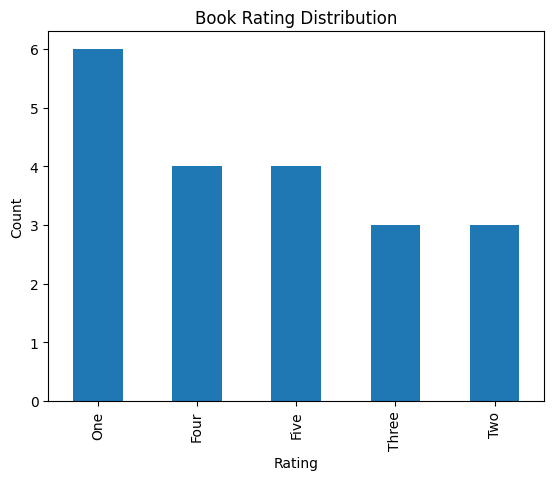

In [ ]:
import matplotlib.pyplot as plt

df["Rating"].value_counts().plot(kind="bar")

plt.title("Book Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

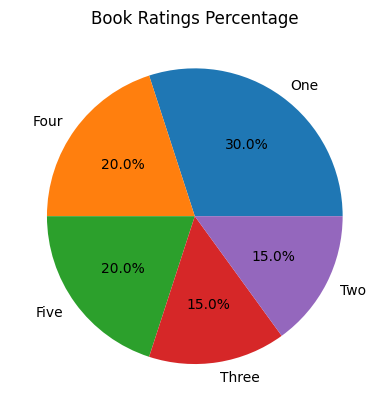

In [ ]:
df["Rating"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Book Ratings Percentage")
plt.ylabel("")

plt.show()

In [ ]:
df["Price"].head()

0    Â51.77
1    Â53.74
2    Â50.10
3    Â47.82
4    Â54.23
Name: Price, dtype: str

In [ ]:
df["Price"] = df["Price"].str.replace("Â", "", regex=False)

df["Price"] = df["Price"].astype(float)

df.head()

,Title,Price,Rating
0,A Light in the Attic,51.77,Three
1,Tipping the Velvet,53.74,One
2,Soumission,50.10,One
3,Sharp Objects,47.82,Four
4,Sapiens: A Brief History of Humankind,54.23,Five


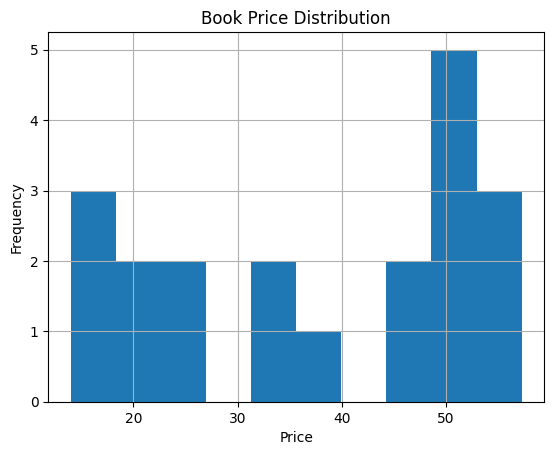

In [ ]:
df["Price"].hist(bins=10)

plt.title("Book Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [ ]:
df.sort_values(
    by="Price",
    ascending=False
).head(10)

,Title,Price,Rating
15,Our Band Could Be Your Life: Scenes from the A...,57.25,Three
4,Sapiens: A Brief History of Humankind,54.23,Five
1,Tipping the Velvet,53.74,One
13,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,Five
9,The Black Maria,52.15,One
0,A Light in the Attic,51.77,Three
18,Libertarianism for Beginners,51.33,Two
2,Soumission,50.10,One
3,Sharp Objects,47.82,Four
19,It's Only the Himalayas,45.17,Two


# Book Data Web Scraping

## Import Libraries

## Download Webpage

## Parse HTML using BeautifulSoup

## Extract Book Information

## Create DataFrame

## Export Data to CSV

## Data Visualization

## Key Findings

## Conclusion